In [30]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.datasets import make_moons

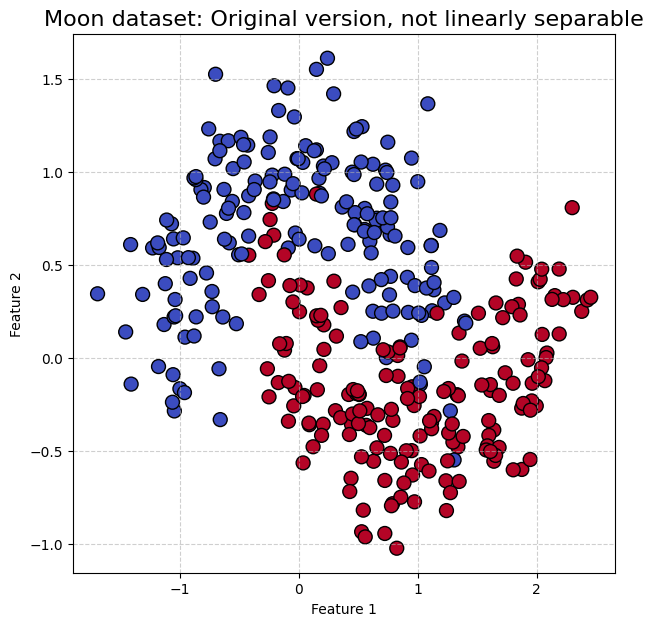

In [31]:
X_np, y_np = make_moons(n_samples=350, noise=0.25, random_state=36)
X = torch.from_numpy(X_np).float()
y = torch.from_numpy(y_np).float().view(-1, 1)

# plotting
plt.figure(figsize=(7, 7))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='coolwarm', s=100, edgecolors='k')
plt.title('Moon dataset: Original version, not linearly separable', fontsize=16)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
# building a model and training it

In [32]:
class Moon_Solver(nn.Module):
    def __init__(self):
        super(Moon_Solver, self).__init__()
        self.hidden1 = nn.Linear(2, 5)   # 2 inputs -> 5 neurons
        self.hidden2 = nn.Linear(5, 3)
        self.hidden3 = nn.Linear(3, 3)
        self.output  = nn.Linear(3, 1)   # 3 -> 1 output

    def forward(self, x):
        # Pass through first hidden layer and apply ReLU
        x = F.relu(self.hidden1(x))
        # Pass through second hidden layer and apply ReLU
        x = F.relu(self.hidden2(x))
        x = F.relu(self.hidden3(x))
        # Pass through output layer and apply Sigmoid
        x = torch.sigmoid(self.output(x))
        return x

model = Moon_Solver()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# training loop
epochs = 200
for epoch in range(epochs):
    y_pred = model(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [200/200], Loss: 0.1995


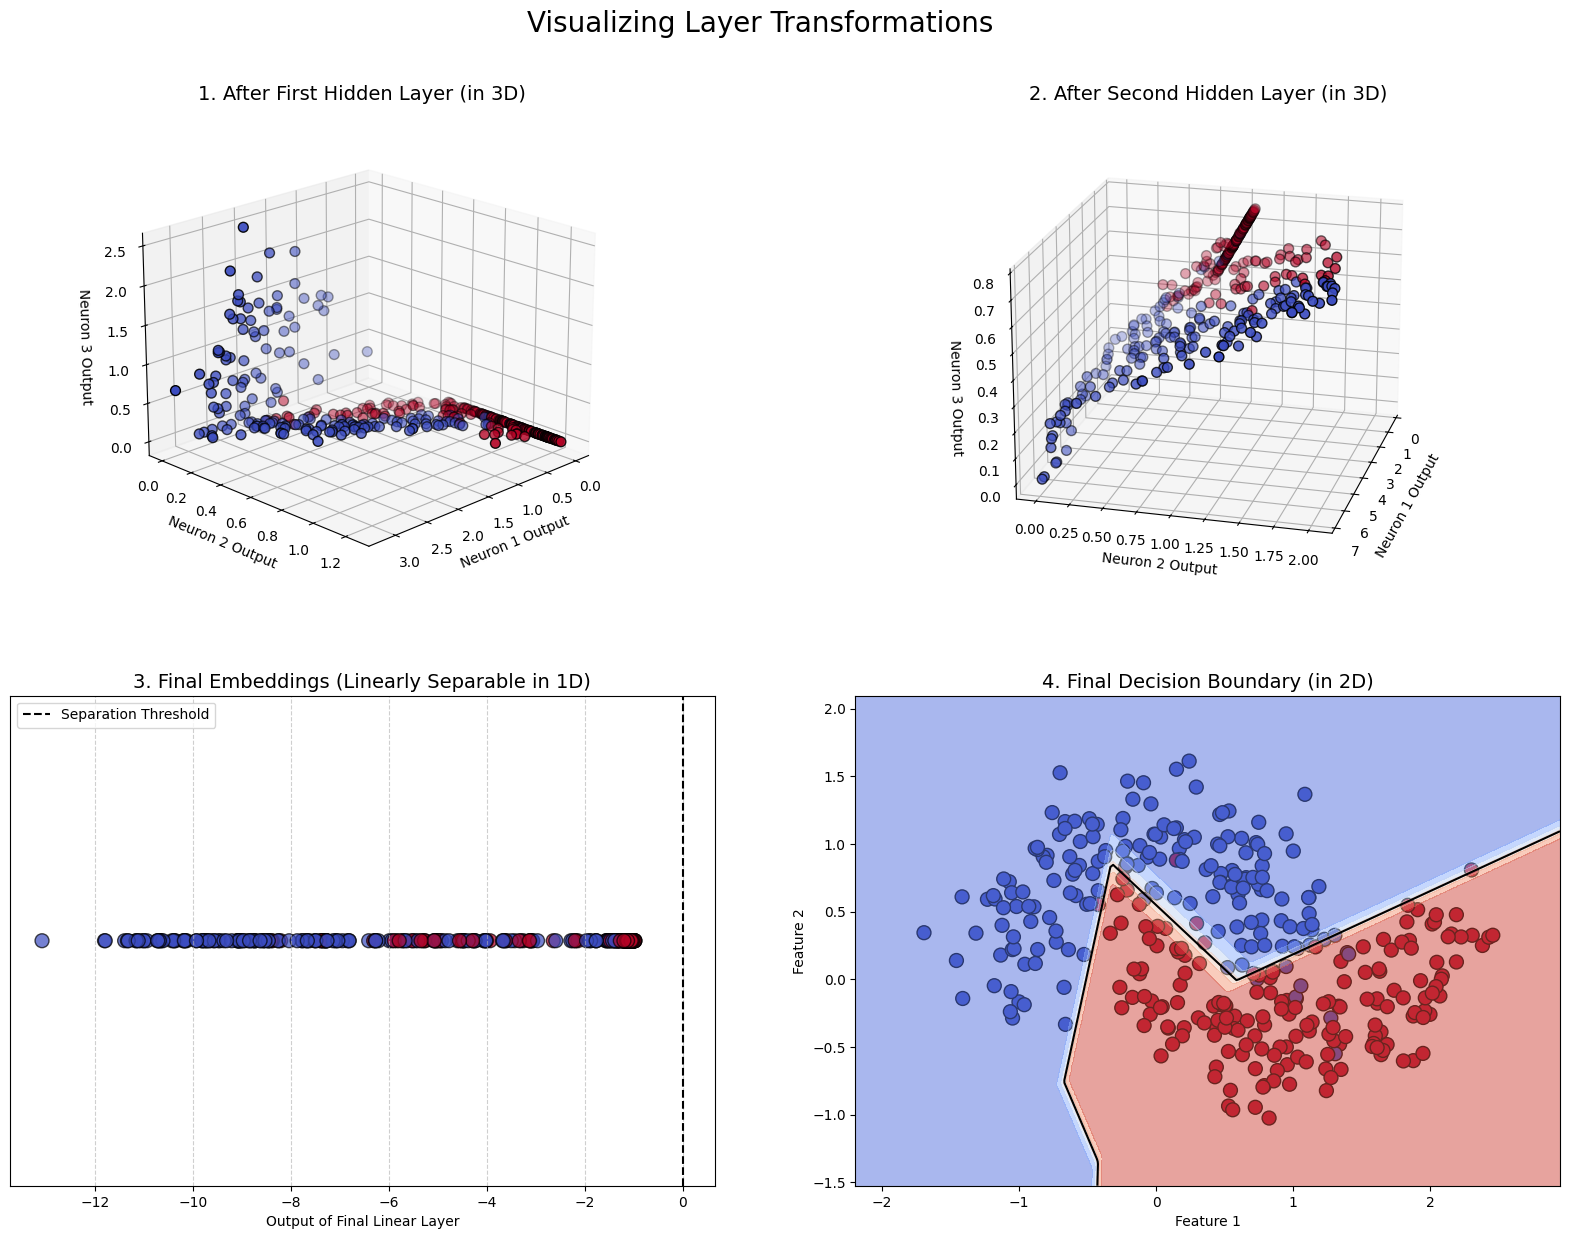

In [33]:
# visualising the output
def get_intermediate_outputs(x):
    out1 = F.relu(model.hidden1(x))
    out2 = F.relu(model.hidden2(out1))
    # Get the raw linear output before the final sigmoid activation
    final_linear_out = model.output(out2)
    final_prob_out = torch.sigmoid(final_linear_out)
    return out1, out2, final_linear_out, final_prob_out

# Get the outputs for our dataset
with torch.no_grad():
    h1_out, h2_out, final_embeddings, _ = get_intermediate_outputs(X)
    h1_out_np = h1_out.numpy()
    h2_out_np = h2_out.numpy()
    final_embeddings_np = final_embeddings.numpy()

# Create plots
fig = plt.figure(figsize=(20, 14))
fig.suptitle("Visualizing Layer Transformations", fontsize=20, y=0.95)

# Plot 1: After 1st Hidden Layer (3D View)
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(h1_out_np[:, 0], h1_out_np[:, 1], h1_out_np[:, 2], c=y_np, cmap='coolwarm', s=50, edgecolors='k')
ax1.set_title("1. After First Hidden Layer (in 3D)", fontsize=14)
ax1.set_xlabel("Neuron 1 Output")
ax1.set_ylabel("Neuron 2 Output")
ax1.set_zlabel("Neuron 3 Output")
ax1.view_init(elev=20, azim=45) # Set a nice viewing angle

# Plot 2: After 2nd Hidden Layer (3D View)
ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(h2_out_np[:, 0], h2_out_np[:, 1], h2_out_np[:, 2], c=y_np, cmap='coolwarm', s=50, edgecolors='k')
ax2.set_title("2. After Second Hidden Layer (in 3D)", fontsize=14)
ax2.set_xlabel("Neuron 1 Output")
ax2.set_ylabel("Neuron 2 Output")
ax2.set_zlabel("Neuron 3 Output")
ax2.view_init(elev=20, azim=15) # Set a different viewing angle

# Plot 3: The Final Embeddings, projected to 1D
ax3 = fig.add_subplot(223)
ax3.scatter(final_embeddings_np, np.zeros_like(final_embeddings_np), c=y_np, cmap='coolwarm', s=100, edgecolors='k', alpha=0.7)
ax3.axvline(0, color='black', linestyle='--', label='Separation Threshold')
ax3.set_title("3. Final Embeddings (Linearly Separable in 1D)", fontsize=14)
ax3.set_xlabel("Output of Final Linear Layer")
ax3.set_yticks([]) # Hide y-axis ticks for clarity
ax3.grid(True, axis='x', linestyle='--', alpha=0.6)
ax3.legend()


# Plot 4: The Final Decision Boundary in the Original 2D Space
ax4 = fig.add_subplot(224)
ax4.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='coolwarm', s=100, edgecolors='k')
ax4.set_title("4. Final Decision Boundary (in 2D)", fontsize=14)
ax4.set_xlabel("Feature 1")
ax4.set_ylabel("Feature 2")

# Create mesh grid for the decision boundary
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

grid_tensor = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()

# Get model predictions on the grid
model.eval()
with torch.no_grad():
    Z = model(grid_tensor).numpy().reshape(xx.shape)

ax4.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.5)
ax4.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='-')

plt.show()

In [43]:
%reset -f

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [45]:
transform = transforms.Compose([
    transforms.ToTensor(), # convert image to tensor
    transforms.Normalize((0.1307,), (0.3081,))  # normalizing to get std = 1, mean = 0 (0.1307 - mean; 0.3081 - std)
])

train_dataset = MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = MNIST(root='./data', train=False, download=True, transform=transform)
# 55000 - train data, 5000 - val data (checking accuracy during training)
train_data, val_data = torch.utils.data.random_split(train_dataset, [55000, 5000])
# loading data in batches - chunks of images
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=256)
test_loader  = DataLoader(test_dataset, batch_size=256)

In [46]:
class Digit_recognizer(nn.Module):
    def __init__(self):
        super(Digit_recognizer, self).__init__()
        self.hidden1 = nn.Linear(784, 256)
        self.hidden2 = nn.Linear(256, 128)
        self.output  = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)        # flatten 28×28 → 784
        x = F.relu(self.hidden1(x))
        x = F.relu(self.hidden2(x))
        x = self.output(x)
        return x

In [47]:
def train(model, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs+1):
        model.train()
        for X, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()

        val_acc = evaluate(model, val_loader)
        print(f"Epoch {epoch:02d} | val acc: {val_acc:.2%}")

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X, y in loader:
            preds = model(X).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
    return correct / total

Epoch 01 | val acc: 95.34%
Epoch 02 | val acc: 96.62%
Epoch 03 | val acc: 97.24%
Epoch 04 | val acc: 97.32%
Epoch 05 | val acc: 97.08%
Epoch 06 | val acc: 97.22%
Epoch 07 | val acc: 97.66%
Epoch 08 | val acc: 97.30%
Epoch 09 | val acc: 97.78%
Epoch 10 | val acc: 97.60%
Test Accuracy: 97.55%

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.99      0.98      1032
           3       0.95      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.96      0.98       892
           6       0.99      0.97      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.98      0.95      0.96       974
           9       0.95      0.98      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
wei

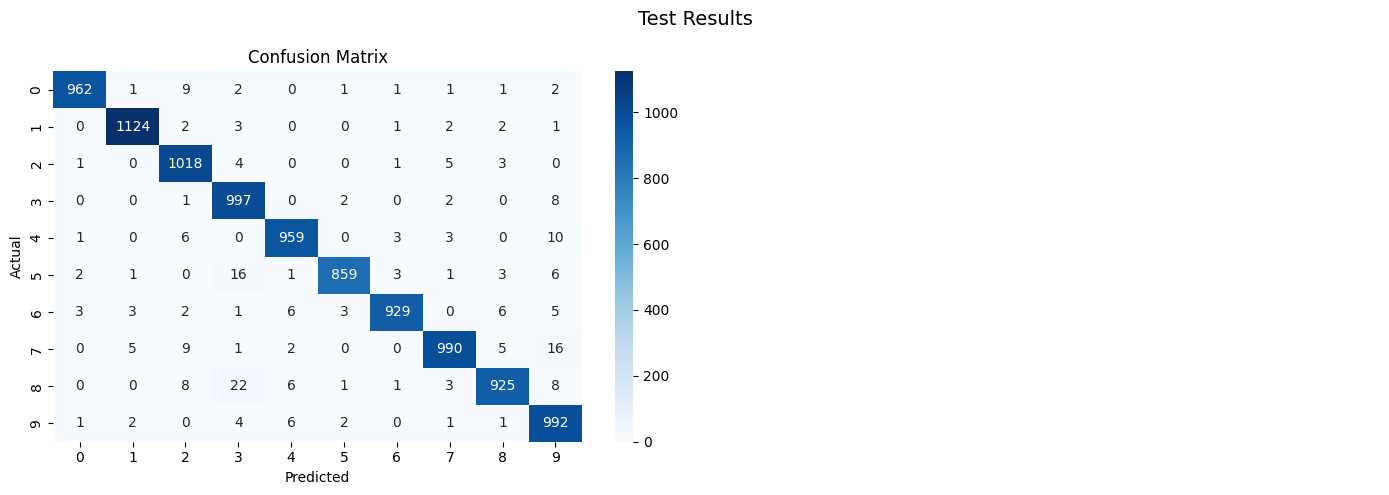

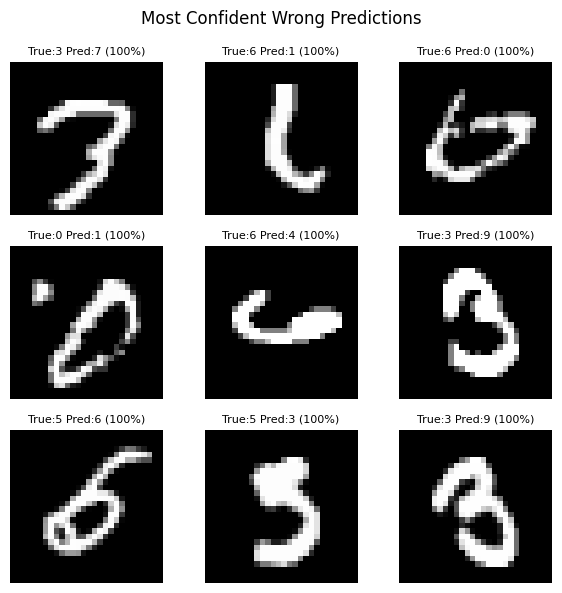

In [48]:
model = Digit_recognizer()
train(model, epochs=10)
# analyzing model:
# Test
all_preds, all_labels, all_probs = [], [], []
model.eval()
with torch.no_grad():
    for X, y in test_loader:
        logits = model(X)
        all_preds.append(logits.argmax(dim=1))
        all_labels.append(y)
        all_probs.append(torch.softmax(logits, dim=1))

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_probs  = torch.cat(all_probs).numpy()

print(f"Test Accuracy: {(all_preds == all_labels).mean():.2%}\n")
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Most confident wrong predictions
wrong_idx  = np.where(all_preds != all_labels)[0]
wrong_conf = all_probs[wrong_idx].max(axis=1)
top9       = wrong_idx[np.argsort(-wrong_conf)[:9]]

axes[1].axis('off')
fig.suptitle("Test Results", fontsize=14)
plt.tight_layout()
plt.show()

# Worst mistakes grid
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
fig.suptitle("Most Confident Wrong Predictions")
for ax, idx in zip(axes.flat, top9):
    img = test_loader.dataset[idx][0].squeeze()
    conf = all_probs[idx, all_preds[idx]]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True:{all_labels[idx]} Pred:{all_preds[idx]} ({conf:.0%})", fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [60]:
class Moon_Solver(nn.Module):
    def __init__(self):
        super(Moon_Solver, self).__init__()
        self.hidden1 = nn.Linear(2, 5)   # 2 inputs → 5 neurons
        self.hidden2 = nn.Linear(5, 3)
        self.hidden3 = nn.Linear(3, 3)
        self.output  = nn.Linear(3, 1)   # 3 → 1 output

    def forward(self, x):
        # Pass through first hidden layer and apply ReLU
        x = F.relu(self.hidden1(x))
        # Pass through second hidden layer and apply ReLU
        x = F.relu(self.hidden2(x))
        x = F.relu(self.hidden3(x))
        # Pass through output layer and apply Sigmoid
        x = torch.sigmoid(self.output(x))
        return x

model = Moon_Solver()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
# training loop
epochs = 200
for epoch in range(epochs):
    y_pred = model(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [200/200], Loss: 0.1424
